<h1><B>PERTANYAAN BISNIS</b></h1>
<p>1. Bagaimana sentimen pengguna terhadap layanan berdasarkan data kuesioner PKKMB periode tahun 2025, serta bagaimana hasil analisis tersebut dapat digunakan untuk meningkatkan kualitas layanan?</p>


<h1><B>IMPORT LIBRARY/PACKAGES YG DIGUNAKAN</b></h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

<h1><B>DATA WRANGLING</b></h1>
<h2><B>GATHERING DATA</b></h2>
<h3>Load dan lihat data</h3>

In [2]:
df = pd.read_csv("Kuesioner_pkkmb.csv", sep=";")
df.head()

,Response,Submitted on:,Q16_KRITIK DAN SARAN,sentimen
0,345836,21/09/2025 01.06,Untuk servernya full dan error jadi agak susah...,negatif
1,306420,17/09/2025 23.02,Sudah baik untuk tahun ini namun akan lebih ba...,positif
2,341608,20/09/2025 18.47,Tolong perbaiki website PPKMB sehingga lebih m...,positif
3,293208,15/09/2025 20.21,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif
4,341272,20/09/2025 18.06,Semoga lebih baik,positif


<h2><B>ASSESSING DATA</b></h2>
<h3>Melihat informasi jumlah baris data, jumlah kolom, nilai non-null, dan data type </h3>


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13001 entries, 0 to 13000
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Response              13001 non-null  int64 
 1   Submitted on:         13001 non-null  object
 2   Q16_KRITIK DAN SARAN  12984 non-null  object
 3   sentimen              13001 non-null  object
dtypes: int64(1), object(3)
memory usage: 406.4+ KB


<h3>Mengecek missing value</h3>

In [4]:
df.isna().sum()

Response                 0
Submitted on:            0
Q16_KRITIK DAN SARAN    17
sentimen                 0
dtype: int64

<h3>Mengecek Jumlah label data</h3>

In [5]:
df['sentimen'].value_counts()

sentimen
positif    4722
netral     4642
negatif    3637
Name: count, dtype: int64

<h3>Mengecek data duplikat</h3>

In [6]:
df['Q16_KRITIK DAN SARAN'].duplicated().sum()

4975

<h2><B>CLEANING DATA</b></h2>
<h3>Mengganti nama kolom</h3>

In [7]:
df.rename(columns={
    'Q16_KRITIK DAN SARAN': 'Kritik dan saran',
    'sentimen': 'Sentimen',
    'Submitted on:': 'Submitted on'
}, inplace=True)

<h3>Menghapus nilai kosong</h3>

In [8]:
df = df.dropna(subset=['Kritik dan saran'])

<h3>Mengecek untuk memastikan tidak ada nilai kosong</h3>

In [9]:
df.isna().sum()

Response            0
Submitted on        0
Kritik dan saran    0
Sentimen            0
dtype: int64

<h3>Mengganti type object ke Datetime pada kolom submitted on</h3>

In [10]:
df['Submitted on'] = df['Submitted on'].str.replace('.', ':', regex=False)
df['Submitted on'] = pd.to_datetime(
    df['Submitted on'],
    format='%d/%m/%Y %H:%M'
)

<h3>Memastikan type object ke Datetime pada kolom submitted on sudah berubah</h3>

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12984 entries, 0 to 13000
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Response          12984 non-null  int64         
 1   Submitted on      12984 non-null  datetime64[ns]
 2   Kritik dan saran  12984 non-null  object        
 3   Sentimen          12984 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 507.2+ KB


<h3>Menghapus data duplikat</h3>

In [12]:
df.drop_duplicates(subset='Kritik dan saran', inplace=True)

<h3>Mengecek Jumlah label setelah dihapus duplikat</h3>

In [13]:
df["Sentimen"].value_counts()

Sentimen
positif    4126
netral     2703
negatif    1196
Name: count, dtype: int64

<h1><B>EDA</b></h1>
<h2><B>EXPLORATORY DATA ANALYST</b></h2>
<h3><B>Melihat parameter statistik dari data</b></h3>

In [14]:
df.describe(include="all")

,Response,Submitted on,Kritik dan saran,Sentimen
count,8025.000000,8025,8025,8025
unique,NaN,NaN,8025,3
top,NaN,NaN,Untuk servernya full dan error jadi agak susah...,positif
freq,NaN,NaN,1,4126
mean,314293.974829,2025-09-17 20:37:49.016822272,NaN,NaN
min,275592.000000,2025-09-10 15:18:00,NaN,NaN
25%,294318.000000,2025-09-15 23:25:00,NaN,NaN
50%,312724.000000,2025-09-18 17:25:00,NaN,NaN
75%,334630.000000,2025-09-20 06:24:00,NaN,NaN
max,355214.000000,2025-09-22 10:40:00,NaN,NaN


<h3><B>Feature engineering waktu</b></h3>

In [15]:
df['Submitted on'] = pd.to_datetime(df['Submitted on'])
df['tanggal'] = df['Submitted on'].dt.date
df['jam'] = df['Submitted on'].dt.hour
df['hari'] = df['Submitted on'].dt.day_name()
# Hitung data

<h3><B>Visualisasi jumlah feedback waktu pengisian PKKMB</b></h3>

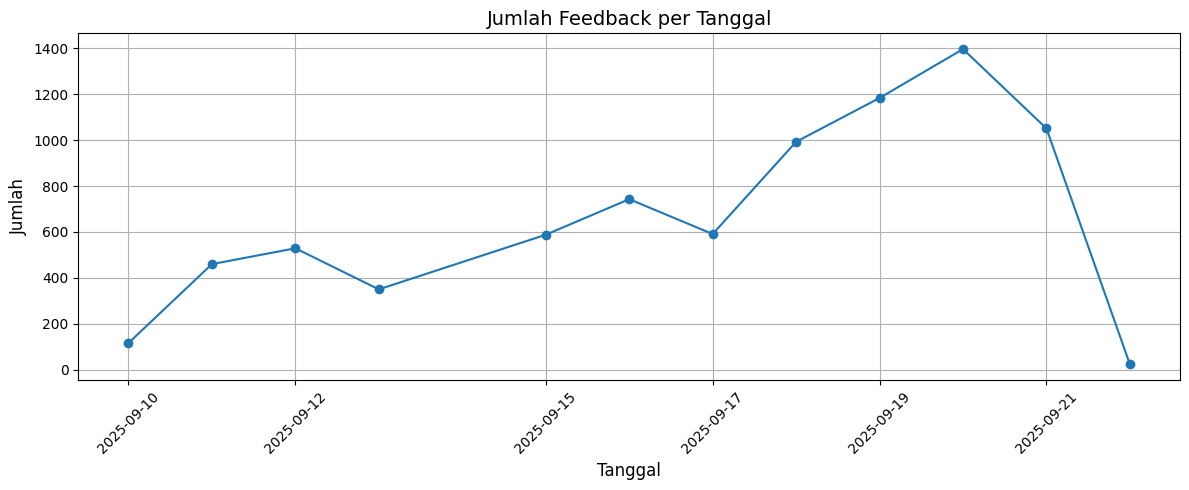

In [16]:

data_plot = df['tanggal'].value_counts().sort_index()

# Buat figure
plt.figure(figsize=(12,5))

# Plot line
plt.plot(data_plot.index, data_plot.values, marker='o')

# Judul & label
plt.title('Jumlah Feedback per Tanggal', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Rotasi tanggal biar gak numpuk
plt.xticks(data_plot.index[::2], rotation=45)  # tampilkan tiap 2 tanggal

# Grid biar enak dibaca
plt.grid()

# Layout biar tidak kepotong
plt.tight_layout()

# Tampilkan
plt.show()

<h3><B>Visualisasi jumlah feedback setiap sentimen</b></h3>

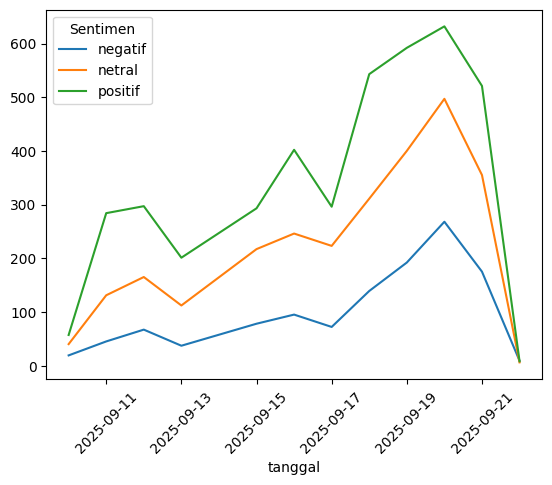

In [ ]:
df.groupby('tanggal')['Sentimen'].value_counts().unstack().plot()
plt.xticks(rotation=45)
plt.show()

<h3><B>Visualisasi Jumlah dari setiap lebel sentimen</b></h3>

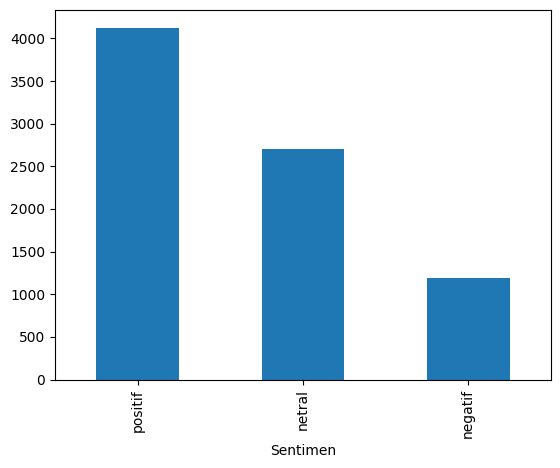

In [ ]:
df['Sentimen'].value_counts().plot(kind='bar')
plt.show()

<h3><B>Analisis Frekuensi Kata</b></h3>

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

corpus = df['Kritik dan saran'].astype(str)
count_vectorizer = CountVectorizer(ngram_range=(1,2), min_df=5)
count_matrix = count_vectorizer.fit_transform(corpus)

word_counts = np.array(count_matrix.sum(axis=0)).flatten()

word_freq = pd.DataFrame({
    'kata': count_vectorizer.get_feature_names_out(),
    'frekuensi': word_counts
}).sort_values(by='frekuensi', ascending=False)

print(word_freq.head(10))

          kata  frekuensi
3451     pkkmb       4781
718        dan       4268
4897      yang       2836
2254     lebih       2508
4575     tidak       2495
4736     untuk       1955
1908  kegiatan       1895
1017        di       1870
3713    sangat       1819
3782      saya       1663


<h3><B>Visualisasi WordCloud sebelum preprocessing</b></h3>

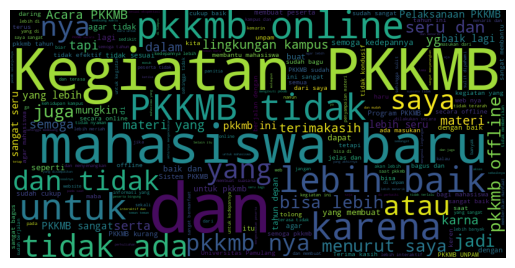

In [ ]:
from wordcloud import WordCloud

all_text = ' '.join(df['Kritik dan saran'].astype(str))
wc = WordCloud(width=800, height=400).generate(all_text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [ ]:
df['Sentimen'].value_counts(normalize=True)

,proportion
Sentimen,
positif,0.514143
netral,0.336822
negatif,0.149034


<h1><B>PREPROCESSING DATA</b></h1>

In [ ]:
!pip install Sastrawi

<h3><B>Text Preprocessing (Stemming & Stopword Removal)
</b></h3>

In [ ]:
import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.tokenize import word_tokenize
# Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stopword
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

<h3><B>Load data slang & Normalisasi Teks (Slang ke Kata Baku)
</b></h3>

In [ ]:

# Load kamus normalisasi
kamus_df = pd.read_excel("Slangword-indonesian.xlsm")
kamus_normalisasi = dict(zip(kamus_df['slang'], kamus_df['formal']))

# Normalisasi langsung (tanpa function)
df['normalisasi'] = df['Kritik dan saran'].astype(str).apply(
    lambda teks: " ".join([kamus_normalisasi.get(kata, kata) for kata in teks.split()])
)

<h3><B>Melakukan Case Folding</b></h3>

In [ ]:
df['case_folding'] = df['normalisasi'].astype(str).str.lower()
df['case_folding'] = df['case_folding'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

<h3><B>Mengunduh dataset/tokenizer yang dibutuhkan oleh NLTK untuk proses tokenisasi teks</b></h3>

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

<h3><B>Proses tokenizing</b></h3>



In [ ]:
# 2. Tokenizing
df['tokenizing'] = df['case_folding'].apply(lambda x: word_tokenize(x))
df.head()

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing
0,345836,2025-09-21 01:06:00,Untuk servernya full dan error jadi agak susah...,negatif,2025-09-21,1,Sunday,Untuk servernya full dan error jadi agak susah...,untuk servernya full dan error jadi agak susah...,"[untuk, servernya, full, dan, error, jadi, aga..."
1,306420,2025-09-17 23:02:00,Sudah baik untuk tahun ini namun akan lebih ba...,positif,2025-09-17,23,Wednesday,Sudah baik untuk tahun ini namun akan lebih ba...,sudah baik untuk tahun ini namun akan lebih ba...,"[sudah, baik, untuk, tahun, ini, namun, akan, ..."
2,341608,2025-09-20 18:47:00,Tolong perbaiki website PPKMB sehingga lebih m...,positif,2025-09-20,18,Saturday,Tolong perbaiki website PPKMB sehingga lebih m...,tolong perbaiki website ppkmb sehingga lebih m...,"[tolong, perbaiki, website, ppkmb, sehingga, l..."
3,293208,2025-09-15 20:21:00,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,2025-09-15,20,Monday,Kegiatan PKKMB tahun ini menurut saya sudah be...,kegiatan pkkmb tahun ini menurut saya sudah be...,"[kegiatan, pkkmb, tahun, ini, menurut, saya, s..."
4,341272,2025-09-20 18:06:00,Semoga lebih baik,positif,2025-09-20,18,Saturday,Semoga lebih baik,semoga lebih baik,"[semoga, lebih, baik]"


<h3><B>Proses Filtering,stemming, dan clean review</b></h3>

In [ ]:
# 3. Filtering (hapus stopwords)
df['filtering'] = df['tokenizing'].apply(lambda tokens: [w for w in tokens if (w not in stopwords) or (w == "tidak")])
# 4. stemming
df['stemming'] = df['filtering'].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)
# Gabungkan hasil stemming jadi kalimat akhir
df['clean_review'] = df['stemming'].apply(lambda tokens: " ".join(tokens))
df.tail(5)

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing,filtering,stemming,clean_review
12973,340744,2025-09-20 17:03:00,Pelaksanaan PKKMB tidak edukatif sehingga suli...,negatif,2025-09-20,17,Saturday,Pelaksanaan PKKMB tidak edukatif sehingga suli...,pelaksanaan pkkmb tidak edukatif sehingga suli...,"[pelaksanaan, pkkmb, tidak, edukatif, sehingga...","[pelaksanaan, pkkmb, tidak, edukatif, sulit, d...","[laksana, pkkmb, tidak, edukatif, sulit, paham]",laksana pkkmb tidak edukatif sulit paham
12974,340762,2025-09-20 17:05:00,Kegiatan PKKMB tidak komunikatif yang akhirnya...,negatif,2025-09-20,17,Saturday,Kegiatan PKKMB tidak komunikatif yang akhirnya...,kegiatan pkkmb tidak komunikatif yang akhirnya...,"[kegiatan, pkkmb, tidak, komunikatif, yang, ak...","[kegiatan, pkkmb, tidak, komunikatif, akhirnya...","[giat, pkkmb, tidak, komunikatif, akhir, kecew...",giat pkkmb tidak komunikatif akhir kecewa serta
12984,327624,2025-09-19 21:43:00,Program PKKMB sangat mengecewakan dan tidak se...,negatif,2025-09-19,21,Friday,Program PKKMB sangat mengecewakan dan tidak se...,program pkkmb sangat mengecewakan dan tidak se...,"[program, pkkmb, sangat, mengecewakan, dan, ti...","[program, pkkmb, sangat, mengecewakan, tidak, ...","[program, pkkmb, sangat, kecewa, tidak, sesuai...",program pkkmb sangat kecewa tidak sesuai ekspe...
12989,290826,2025-09-15 14:02:00,Pelaksanaan PKKMB tidak jelas sehingga membuan...,negatif,2025-09-15,14,Monday,Pelaksanaan PKKMB tidak jelas sehingga membuan...,pelaksanaan pkkmb tidak jelas sehingga membuan...,"[pelaksanaan, pkkmb, tidak, jelas, sehingga, m...","[pelaksanaan, pkkmb, tidak, jelas, membuang, w...","[laksana, pkkmb, tidak, jelas, buang, waktu]",laksana pkkmb tidak jelas buang waktu
12995,279478,2025-09-11 17:42:00,Pelaksanaan PKKMB tidak kondusif yang membuat ...,negatif,2025-09-11,17,Thursday,Pelaksanaan PKKMB tidak kondusif yang membuat ...,pelaksanaan pkkmb tidak kondusif yang membuat ...,"[pelaksanaan, pkkmb, tidak, kondusif, yang, me...","[pelaksanaan, pkkmb, tidak, kondusif, membuat,...","[laksana, pkkmb, tidak, kondusif, buat, serta,...",laksana pkkmb tidak kondusif buat serta bingung


<h3><B>Mapping sentimen ke sentimen biner</b></h3>

In [ ]:
df['Sentimen_Biner'] = df['Sentimen'].map({
    'positif': 1,
    'negatif': -1,
    'netral': 0
})
df.head(20)

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing,filtering,stemming,clean_review,Sentimen_Biner
0,345836,2025-09-21 01:06:00,Untuk servernya full dan error jadi agak susah...,negatif,2025-09-21,1,Sunday,Untuk servernya full dan error jadi agak susah...,untuk servernya full dan error jadi agak susah...,"[untuk, servernya, full, dan, error, jadi, aga...","[servernya, full, error, jadi, susah, mengerja...","[servernya, full, error, jadi, susah, kerja]",servernya full error jadi susah kerja,-1
1,306420,2025-09-17 23:02:00,Sudah baik untuk tahun ini namun akan lebih ba...,positif,2025-09-17,23,Wednesday,Sudah baik untuk tahun ini namun akan lebih ba...,sudah baik untuk tahun ini namun akan lebih ba...,"[sudah, baik, untuk, tahun, ini, namun, akan, ...","[baik, tahun, lebih, baik, laksanakan, langsun...","[baik, tahun, lebih, baik, laksana, langsung, ...",baik tahun lebih baik laksana langsung terima ...,1
2,341608,2025-09-20 18:47:00,Tolong perbaiki website PPKMB sehingga lebih m...,positif,2025-09-20,18,Saturday,Tolong perbaiki website PPKMB sehingga lebih m...,tolong perbaiki website ppkmb sehingga lebih m...,"[tolong, perbaiki, website, ppkmb, sehingga, l...","[perbaiki, website, ppkmb, lebih, mudah, cepat...","[baik, website, ppkmb, lebih, mudah, cepat, ak...",baik website ppkmb lebih mudah cepat akses,1
3,293208,2025-09-15 20:21:00,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,2025-09-15,20,Monday,Kegiatan PKKMB tahun ini menurut saya sudah be...,kegiatan pkkmb tahun ini menurut saya sudah be...,"[kegiatan, pkkmb, tahun, ini, menurut, saya, s...","[kegiatan, pkkmb, tahun, berjalan, baik, membe...","[giat, pkkmb, tahun, jalan, baik, beri, banyak...",giat pkkmb tahun jalan baik beri banyak inform...,1
4,341272,2025-09-20 18:06:00,Semoga lebih baik,positif,2025-09-20,18,Saturday,Semoga lebih baik,semoga lebih baik,"[semoga, lebih, baik]","[semoga, lebih, baik]","[moga, lebih, baik]",moga lebih baik,1
5,294142,2025-09-15 22:57:00,Perbaiki lagi sistem websitenya agar ngga lemot,netral,2025-09-15,22,Monday,Perbaiki lagi sistem websitenya agar enggak lemot,perbaiki lagi sistem websitenya agar enggak lemot,"[perbaiki, lagi, sistem, websitenya, agar, eng...","[perbaiki, sistem, websitenya, enggak, lemot]","[baik, sistem, websitenya, enggak, lot]",baik sistem websitenya enggak lot,0
6,346872,2025-09-21 02:18:00,kedepannya unpam semakin maju,netral,2025-09-21,2,Sunday,kedepannya unpam semakin maju,kedepannya unpam semakin maju,"[kedepannya, unpam, semakin, maju]","[kedepannya, unpam, semakin, maju]","[depan, unpam, makin, maju]",depan unpam makin maju,0
7,354138,2025-09-21 19:07:00,“Saya merasa kegiatan PKKMB sudah berjalan den...,positif,2025-09-21,19,Sunday,“Saya merasa kegiatan PKKMB sudah berjalan den...,saya merasa kegiatan pkkmb sudah berjalan deng...,"[saya, merasa, kegiatan, pkkmb, sudah, berjala...","[merasa, kegiatan, pkkmb, berjalan, baik, satu...","[rasa, giat, pkkmb, jalan, baik, satu, perlu, ...",rasa giat pkkmb jalan baik satu perlu tingkat ...,1
8,316126,2025-09-18 23:38:00,tidak ada semua sudah bagus dan cukup,positif,2025-09-18,23,Thursday,tidak ada semua sudah bagus dan cukup,tidak ada semua sudah bagus dan cukup,"[tidak, ada, semua, sudah, bagus, dan, cukup]","[tidak, semua, bagus, cukup]","[tidak, semua, bagus, cukup]",tidak semua bagus cukup,1
9,294646,2025-09-16 00:03:00,"materi yang disampaikan baik, dan jelas. dapat...",positif,2025-09-16,0,Tuesday,"materi yang disampaikan baik, dan jelas. dapat...",materi yang disampaikan baik dan jelas dapat d...,"[materi, yang, disampaikan, baik, dan, jelas, ...","[materi, disampaikan, baik, jelas, dimengerti,...","[materi, sampai, baik, jelas, erti, baik, maba...",materi sampai baik jelas erti baik maba ikut g...,1


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Ambil teks bersih
corpus = df['clean_review'].astype(str)

# Inisialisasi TF-IDF (unigram + bigram supaya lebih kaya fitur)
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=5)

# Fit dan transform
tfidf_matrix = vectorizer.fit_transform(corpus)

# Cek ukuran matrix
print("TF-IDF matrix shape:", tfidf_matrix.shape)

# Lihat 20 fitur pertama
print(vectorizer.get_feature_names_out()[:10])

TF-IDF matrix shape: (8025, 3327)
['aamiin' 'absen' 'absensi' 'ac' 'ac kurang' 'ac nya' 'acara' 'acara baik'
 'acara buat' 'acara jalan']


In [ ]:
df.to_csv('Sentimen_Cleaned.csv', index=False)

# TES

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Create 'Sentimen_Biner' column based on 'Rating'
df['Sentimen_Biner'] = df['Sentimen'].map({
    'positif': 1,
    'negatif': -1,
    'netral': 0
})
# Ambil fitur (TF-IDF) dan target (label sentimen)
X = tfidf_matrix
y = df['Sentimen_Biner'] # use the new column

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model klasifikasi (contoh Logistic Regression)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Prediksi
y_pred = clf.predict(X_test)

# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Negatif", "Positif","Netral"]))

Akurasi: 0.8573208722741433
              precision    recall  f1-score   support

     Negatif       0.97      0.79      0.87       239
     Positif       0.78      0.80      0.79       541
      Netral       0.88      0.91      0.90       825

    accuracy                           0.86      1605
   macro avg       0.88      0.83      0.85      1605
weighted avg       0.86      0.86      0.86      1605



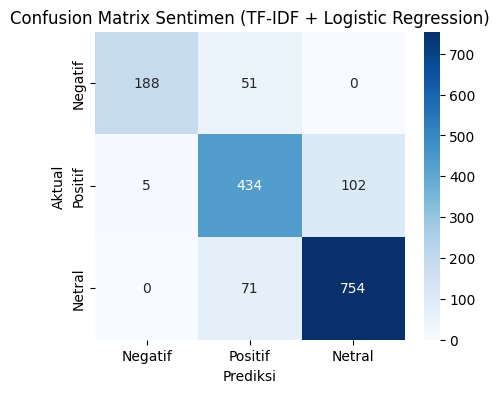

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi dengan heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Negatif", "Positif","Netral"],
            yticklabels=["Negatif", "Positif","Netral"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Sentimen (TF-IDF + Logistic Regression)")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D

# ======================================
# 1. Tokenisasi dan padding
# ======================================
max_words = 10000   # jumlah kata unik maksimum
max_len = 200       # panjang sequence maksimum

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_review'])

X_seq = tokenizer.texts_to_sequences(df['clean_review'])
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post')

# Target
y = df['Sentimen_Biner']

# Split train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# ======================================
# 2. Model LSTM
# ======================================
model_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

print(model_lstm.summary())

# Training LSTM
history_lstm = model_lstm.fit(X_train, y_train,
                              epochs=5,
                              batch_size=32,
                              validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 50s 241ms/step - accuracy: 0.3369 - loss: 0.6618 - val_accuracy: 0.3371 - val_loss: 0.6578
Epoch 2/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 48s 241ms/step - accuracy: 0.3368 - loss: 0.6603 - val_accuracy: 0.3371 - val_loss: 0.6571
Epoch 3/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 81s 236ms/step - accuracy: 0.3368 - loss: 0.6604 - val_accuracy: 0.3371 - val_loss: 0.6566
Epoch 4/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 48s 238ms/step - accuracy: 0.3368 - loss: 0.6592 - val_accuracy: 0.3371 - val_loss: 0.6585
Epoch 5/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 48s 236ms/step - accuracy: 0.3368 - loss: 0.6601 - val_accuracy: 0.3371 - val_loss: 0.6567


In [ ]:
# ======================================
# 3. Model CNN
# ======================================
model_cnn = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

print(model_cnn.summary())

# Training CNN
history_cnn = model_cnn.fit(X_train, y_train,
                            epochs=5,
                            batch_size=32,
                            validation_data=(X_test, y_test))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.5601 - loss: -75.6376 - val_accuracy: 0.6206 - val_loss: -505.2390
Epoch 2/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.6213 - loss: -5040.3706 - val_accuracy: 0.6218 - val_loss: -15202.6553
Epoch 3/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.6293 - loss: -44709.8320 - val_accuracy: 0.6174 - val_loss: -91505.1094
Epoch 4/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.6285 - loss: -181771.8281 - val_accuracy: 0.6174 - val_loss: -307506.4375
Epoch 5/5
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.6307 - loss: -501884.2500 - val_accuracy: 0.6212 - val_loss: -758231.9375


In [ ]:
import matplotlib.pyplot as plt

# Fungsi untuk plot history
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    # Plot akurasi
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Plot untuk LSTM
plot_history(history_lstm, "LSTM")

# Plot untuk CNN
plot_history(history_cnn, "CNN")

51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step


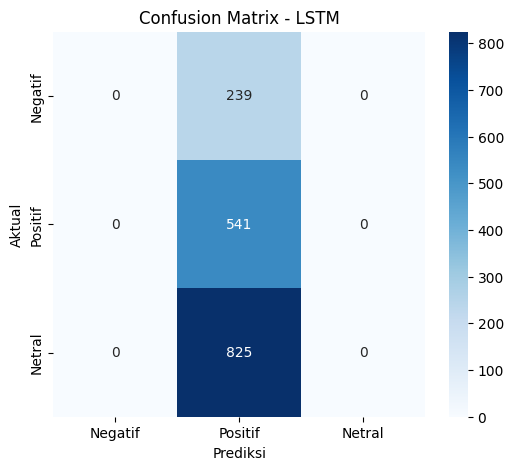

=== LSTM ===
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       239
     Positif       0.34      1.00      0.50       541
      Netral       0.00      0.00      0.00       825

    accuracy                           0.34      1605
   macro avg       0.11      0.33      0.17      1605
weighted avg       0.11      0.34      0.17      1605

 5/51 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


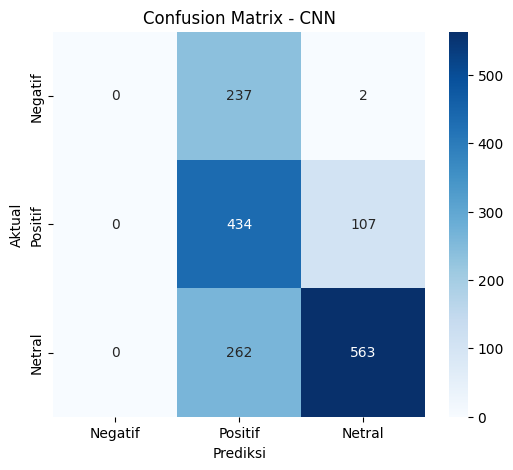

=== CNN ===
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00       239
     Positif       0.47      0.80      0.59       541
      Netral       0.84      0.68      0.75       825

    accuracy                           0.62      1605
   macro avg       0.43      0.49      0.45      1605
weighted avg       0.59      0.62      0.59      1605



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ====== Confusion Matrix Function ======
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Negatif", "Positif","Netral"]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    print(f"=== {title} ===")
    print(classification_report(y_true, y_pred, target_names=labels))


# ====== Evaluasi LSTM ======
y_pred_lstm = (model_lstm.predict(X_test) > 0.5).astype("int32")
plot_confusion(y_test, y_pred_lstm, "LSTM")

# ====== Evaluasi CNN ======
y_pred_cnn = (model_cnn.predict(X_test) > 0.5).astype("int32")
plot_confusion(y_test, y_pred_cnn, "CNN")

Undersampling positif

In [ ]:
df_pos = df[df['Sentimen'] == 'positif']
df_neg = df[df['Sentimen'] == 'negatif']
df_net = df[df['Sentimen'] == 'netral']

df_pos_sample = df_pos.sample(1196, random_state=42)
df_net_sample = df_net.sample(1196, random_state=42)

df_balanced = pd.concat([df_pos_sample, df_net_sample, df_neg])

Pisahkan fitur (X) dan label (y)

In [ ]:
X = df_balanced['Kritik dan saran']
y = df_balanced['Sentimen']

Ubah teks jadi angka

In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

Split data (train & test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training model

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Evaluasi model

In [ ]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7506963788300836


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     negatif       0.90      0.77      0.83       230
      netral       0.58      0.77      0.66       223
     positif       0.84      0.72      0.77       265

    accuracy                           0.75       718
   macro avg       0.77      0.75      0.76       718
weighted avg       0.78      0.75      0.76       718

